# Figure 8: From ideal FTH intensity to a detector measurement

This notebook passes the production FTH result to the repository's detector-effects model. A common count scale gives a maximum of 20,000 expected counts across the two helicities. One count per photon, unit efficiency, one-second exposure and one frame are assumed. This is a declared synthetic count budget, not an absolute beamline-flux prediction.

The experiment includes Poisson statistics, 2-count readout standard deviation, a 3-pixel-radius beamstop, a 16,000-count saturation threshold, mean 12 hot and 12 cold pixels, and mean 2 cosmic-ray events per second. Camera seed 31 keeps defect positions fixed across the helicity pair; noise seeds 17 and 18 give different exposures. The helper also seeds and restores NumPy's legacy RNG because the current readout implementation uses it. Photon splatting is disabled here.

Data are already on a reciprocal grid, so this exercise bypasses flat-detector projection. This isolates the detector-effects stage. A physical detector example must also project onto its pixel coordinates and correct geometry before reconstruction.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/scattering_calculator").is_dir())
PAPER = ROOT / "paper/scattering_calculator"
sys.path.insert(0, str(PAPER))
import experiments as ex
OUT = PAPER / "results"
OUT.mkdir(exist_ok=True)

def show(name):
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.imshow(plt.imread(OUT / (name + ".png")))
    ax.axis("off")
    plt.show()


## Editable sample and geometry

Change these values and Run All. The settings below override the reference numbers in the introductory prose. The FTH calculation uses a uniform momentum grid; physical detector pitch and distance are configured in the skyrmion notebooks.

In [2]:
# EDIT HERE. Film/aperture dimensions and sampling are in nm.
sample_cfg = ex.FTHConfig(
    energy_eV=778.0,
    n=192, dx_nm=10.0,
    layers_nm=(('Au',300.), ('SiN',20.), ('Pt',2.), ('Co',10.), ('Pt',2.)),
    max_slice_nm=5.0,
    object_radius_nm=180.0,
    reference_radius_nm=30.0,
    reference_xy_nm=(600.0, 0.0),
    beam_sigma_nm=650.0,
    domain_period_nm=110.0,
    propagate=True,
    energies_eV=(772.,775.,778.,780.,783.,790.,795.,800.),
)
OUT = PAPER / 'results' / 'notebook_fth'
OUT.mkdir(parents=True, exist_ok=True)


In [3]:
# EDIT HERE. This stage works on a common q grid, not a physical detector plane.
# Flat-detector distance/pitch and Ewald geometry are in the skyrmion notebook.
detector_cfg = ex.DetectorEffectsConfig(
    expected_peak_counts=20000.,
    beamstop_radius_px=3.,
    noise_seed=17,  # CL gets seed + 1
    measurement=dict(number_frames=1, exposure_time=1., max_counts_per_image=None),
    detector=dict(counts_per_photon=1., quantum_efficiency=1.,
                  readout_noise_average=0., readout_noise_sigma=2.,
                  detector_threshold=16000.),
    artifacts=dict(sigma_photon=0., camera_seed=31, average_hot_pixels=12.,
                   average_cold_pixels=12., cosmic_rays_per_second=2.),
)
OUT = PAPER / 'results' / 'notebook_detector'
OUT.mkdir(parents=True, exist_ok=True)


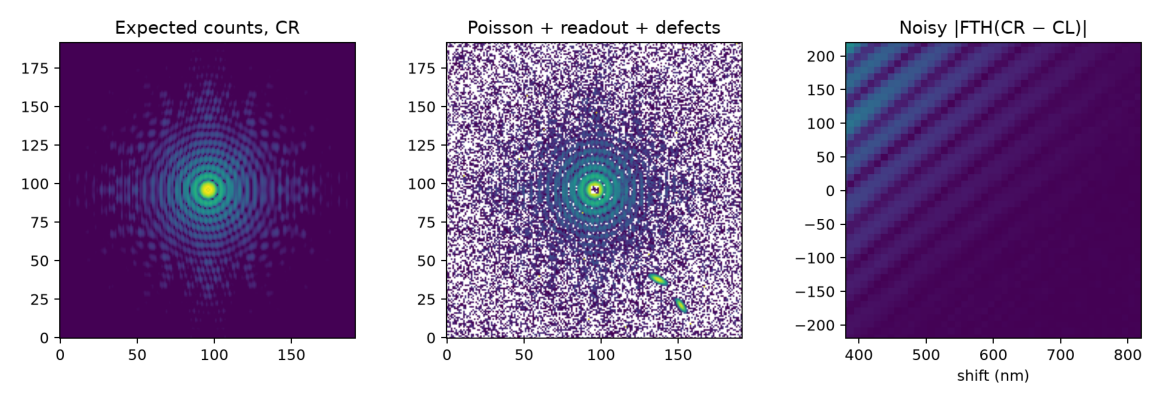

In [4]:
ex.provenance(OUT, {'notebook': 'paper_03', 'noise_seeds': [17,18], 'camera_seed':31})
measured = ex.detector_figure(OUT, sample_config=sample_cfg, detector_config=detector_cfg)
show('fig08_detector')

Compare the sideband against Figure 5. Masking and detector defects create Fourier-space convolution artifacts; filling a beamstop with zero does not recover the lost low-q information. No inpainting or denoising is silently applied.